# Retail Sales Analytics and Customer Intelligence

This notebook is a short walkthrough of the analysis in this project. It
uses the Online Retail II dataset (UCI Machine Learning Repository) and
covers data cleaning, SQL business queries, exploratory analysis,
forecasting, customer segmentation, churn prediction, price estimation,
and product recommendations.

All of the heavy lifting happens in the scripts under `scripts/`. This
notebook mostly loads the results those scripts already produced under
`outputs/` and comments on what they show. Run `python run_pipeline.py`
first if the `outputs/` and `data/processed/` folders are empty.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", None)

## 1. Dataset overview

The raw data comes from the UCI "Online Retail II" dataset: about 1.07
million transaction lines from a UK-based online gift retailer, covering
December 2009 to December 2011.

In [2]:
retail = pd.read_csv("../data/processed/retail_clean.csv", parse_dates=["invoice_date"])
purchases = pd.read_csv("../data/processed/purchases_clean.csv", parse_dates=["invoice_date"])

print("Cleaned transaction rows:", len(retail))
print("Date range:", retail["invoice_date"].min(), "to", retail["invoice_date"].max())
print("Unique customers (with an ID):", retail["customer_id"].nunique())
print("Unique products:", retail["stock_code"].nunique())
print("Countries:", retail["country"].nunique())
retail.head()

Cleaned transaction rows: 1033030
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers (with an ID): 5942
Unique products: 5304
Countries: 43


,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled,revenue,year,month,year_month,week,day_of_week,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,2009-12,49,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,2009-12,49,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,2009-12,49,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,2009-12,49,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,2009-12,49,Tuesday,7


## 2. Cleaning summary

The raw file has two sheets (2009-2010 and 2010-2011) that get combined
into 1,067,371 rows. From there:

- 34,335 exact duplicate rows were dropped
- 6 "Adjust bad debt" accounting rows were dropped (not real product sales)
- missing product descriptions were filled in from other rows with the
  same stock code, the rest were labeled "UNKNOWN ITEM"
- that leaves 1,033,030 rows in `retail_clean.csv`, which still includes
  cancelled orders and orders with no customer ID, since those matter for
  business level questions like cancellation rate

For anything that models customer or product behavior, a stricter
`purchases_clean.csv` is used instead: completed orders only, real
products only (postage, discounts, manual adjustments etc are excluded),
positive quantity and price, and a known customer ID.

In [3]:
print("purchases_clean.csv rows:", len(purchases))
print("customers:", purchases["customer_id"].nunique())
print("products:", purchases["stock_code"].nunique())

purchases_clean.csv rows: 776840
customers: 5853
products: 4624


## 3. A few exploratory results

Full set of charts is under `outputs/figures/`, here are three that stood
out while looking through the data.

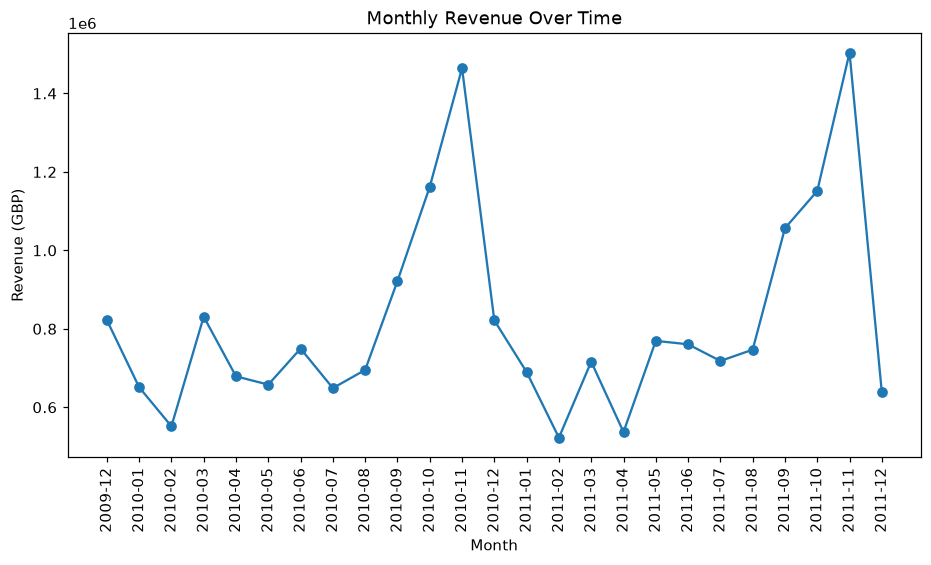

In [4]:
display(Image("../outputs/figures/01_monthly_revenue_trend.png"))

Revenue is clearly seasonal, with a strong run-up into November each year before the holiday period, then a drop in December once the data cuts off mid-month.

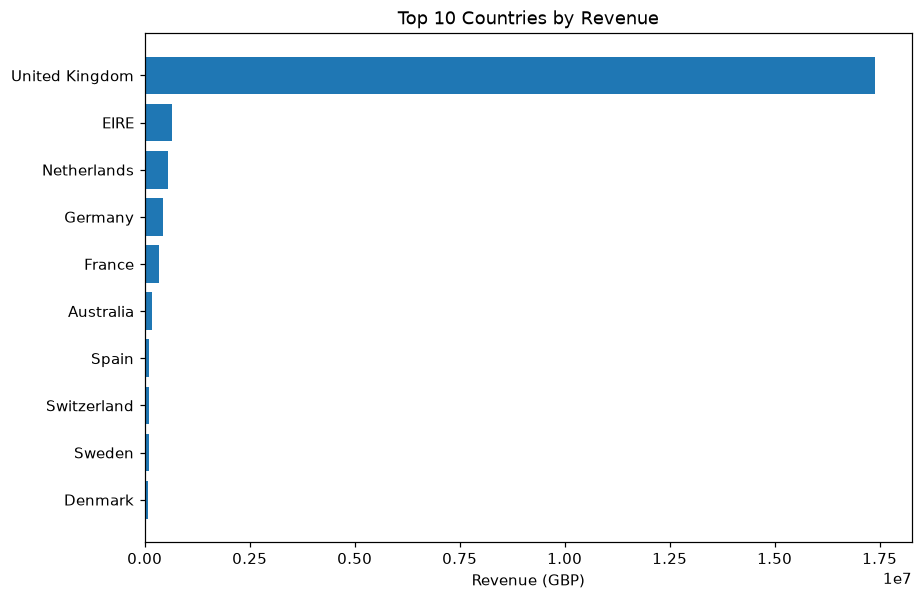

In [5]:
display(Image("../outputs/figures/05_revenue_by_country.png"))

The business is overwhelmingly UK based. Everything else (EIRE, Netherlands, Germany, France, ...) is a small fraction of total revenue, which is worth keeping in mind when reading any of the country level breakdowns.

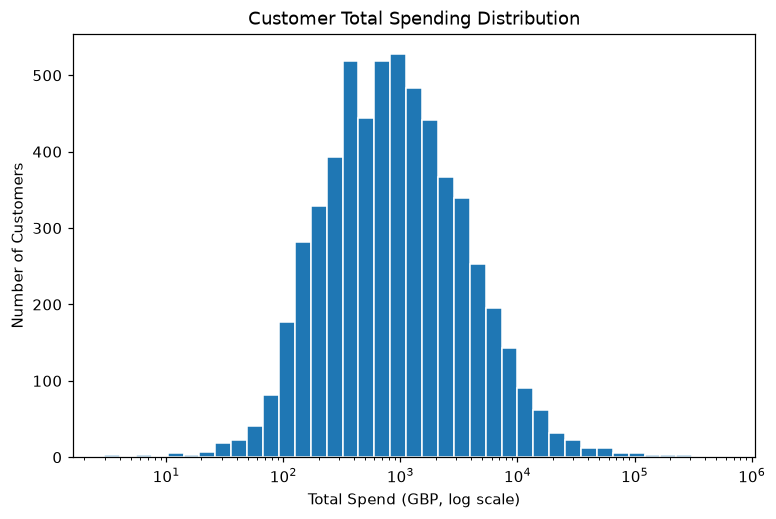

In [6]:
display(Image("../outputs/figures/09_customer_spending_distribution.png"))

Customer spending is heavily right skewed, most customers spend a modest amount and a small group of high spenders pulls the average up a lot. That is part of why the RFM segmentation later uses log transformed values.

## 4. SQL business queries

`sql/business_queries.sql` answers a set of standard business questions
directly in SQL against a SQLite database built from the cleaned data.
Results are saved under `outputs/tables/`.

In [7]:
total_revenue = pd.read_csv("../outputs/tables/total_revenue.csv")
order_count = pd.read_csv("../outputs/tables/order_count.csv")
aov = pd.read_csv("../outputs/tables/average_order_value.csv")
cancellation = pd.read_csv("../outputs/tables/cancellation_rate.csv")

print("Total revenue (completed orders):", total_revenue["total_revenue"].iloc[0])
print("Completed orders:", order_count["order_count"].iloc[0])
print("Average order value:", aov["average_order_value"].iloc[0])
print("Cancellation rate:", cancellation["cancellation_pct"].iloc[0], "%")

Total revenue (completed orders): 20465198.39
Completed orders: 45330
Average order value: 451.47
Cancellation rate: 15.46 %


In [8]:
top_products = pd.read_csv("../outputs/tables/top_products_by_revenue.csv")
top_products.head(10)

,stock_code,description,total_revenue
0,M,Manual,339226.24
1,22423,REGENCY CAKESTAND 3 TIER,330590.32
2,DOT,DOTCOM POSTAGE,309854.11
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20
4,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5,47566,PARTY BUNTING,148318.28
6,85099B,JUMBO BAG RED RETROSPOT,145961.83
7,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49
8,POST,POSTAGE,125682.42
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29


In [9]:
monthly_revenue = pd.read_csv("../outputs/tables/monthly_revenue.csv")
monthly_revenue.head(12)

,year_month,monthly_revenue,order_count
0,2009-12,822483.95,1929
1,2010-01,651155.11,1333
2,2010-02,551504.73,1729
3,2010-03,830915.26,1960
4,2010-04,678875.25,1587
5,2010-05,657705.50,2011
6,2010-06,749537.31,1859
7,2010-07,648810.27,1672
8,2010-08,695251.91,1604
9,2010-09,921696.99,2004


## 5. Sales forecasting

`scripts/sales_forecasting.py` aggregates completed orders into weekly
revenue and compares a naive baseline (next week = this week) against a
regression model using lag and rolling average features, split
chronologically so the model never trains on future weeks.

In [10]:
metrics = pd.read_csv("../outputs/metrics/model_metrics.csv")
metrics[metrics["model"].str.contains("sales_forecast")]

,model,metric,value
0,sales_forecast_baseline,MAE,53620.99
1,sales_forecast_baseline,RMSE,66031.40
2,sales_forecast_linear_regression,MAE,52379.80
3,sales_forecast_linear_regression,RMSE,64765.13


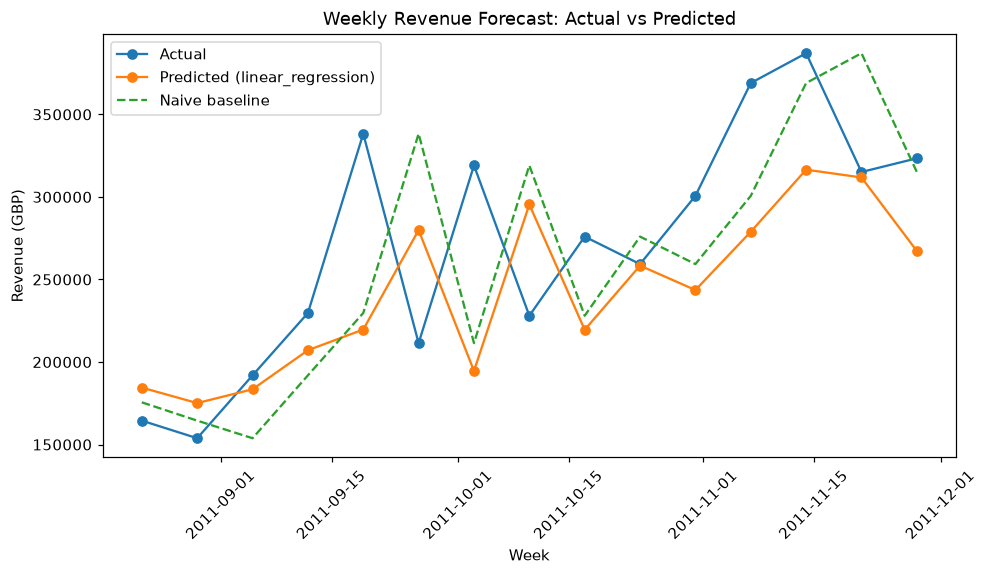

In [11]:
display(Image("../outputs/figures/12_sales_forecast_actual_vs_predicted.png"))

The model beats the naive baseline, but only by a modest margin. Weekly revenue for this business is noisy and driven by a small number of large orders, so this is a realistic result rather than a highly polished one.

## 6. Product demand prediction

`scripts/demand_prediction.py` predicts next week's unit demand for the
50 best selling products, using lag features at the product-week level.

In [12]:
metrics[metrics["model"] == "demand_prediction"]

,model,metric,value
4,demand_prediction,MAE,276.25
5,demand_prediction,RMSE,519.96


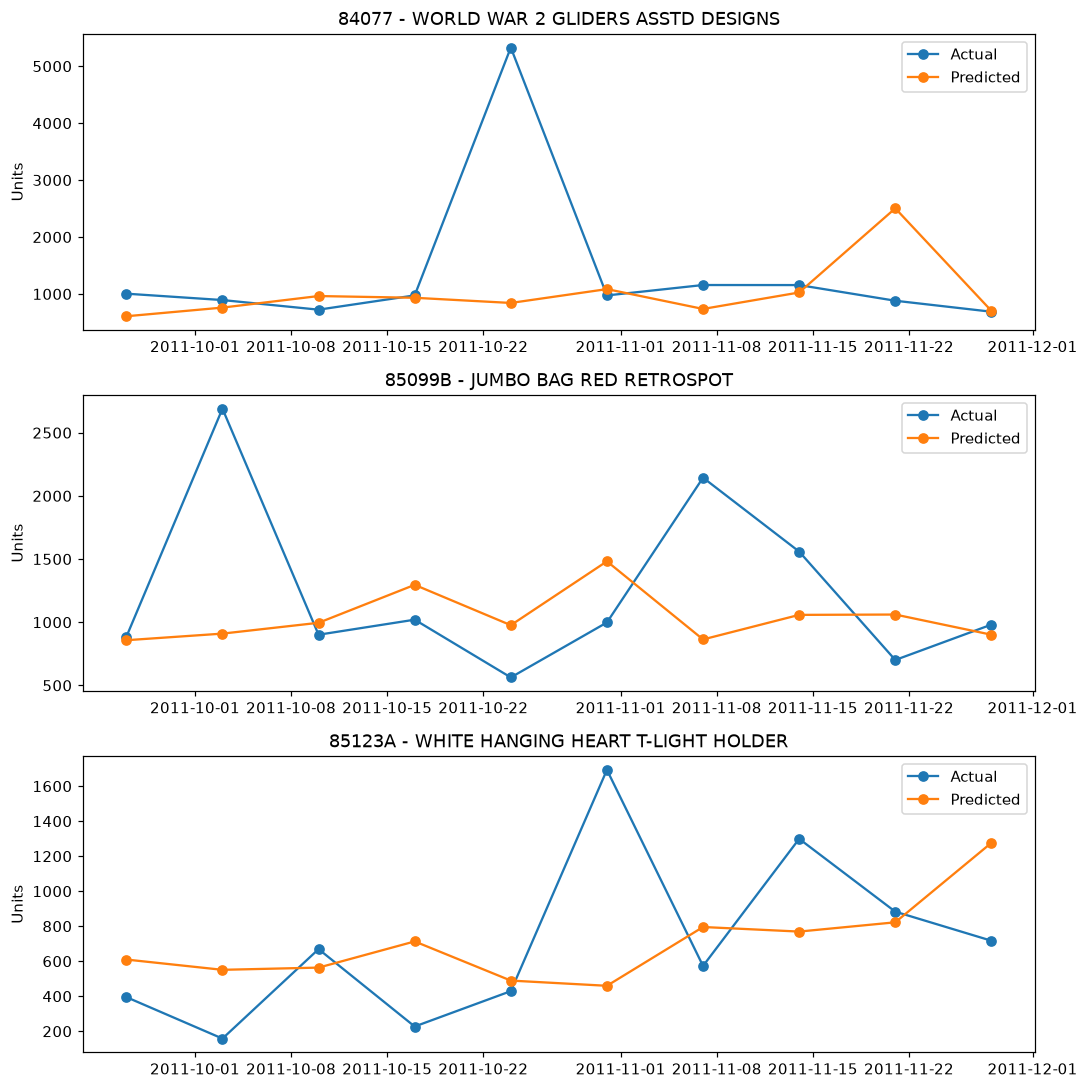

In [13]:
display(Image("../outputs/figures/13_demand_prediction_examples.png"))

The model tracks the general demand level reasonably well but misses some of the large spikes, which are likely bulk or wholesale orders that are hard to predict from recent sales alone.

## 7. Customer segmentation (RFM)

`scripts/customer_segmentation.py` computes Recency, Frequency, and
Monetary value per customer and clusters them with KMeans.

In [14]:
segments = pd.read_csv("../outputs/tables/customer_segments.csv")
segment_summary = pd.read_csv("../outputs/tables/customer_segment_summary.csv")
segment_summary[["cluster", "segment_name", "customers", "avg_recency", "avg_frequency", "avg_monetary"]]

,cluster,segment_name,customers,avg_recency,avg_frequency,avg_monetary
0,0,High Value,1186,28.022766,19.185497,10641.646417
1,1,At Risk,1452,227.740358,5.075758,1919.729263
2,2,Lapsed,1969,392.575419,1.378873,317.230747
3,3,Occasional,1246,28.220706,3.028892,841.909222


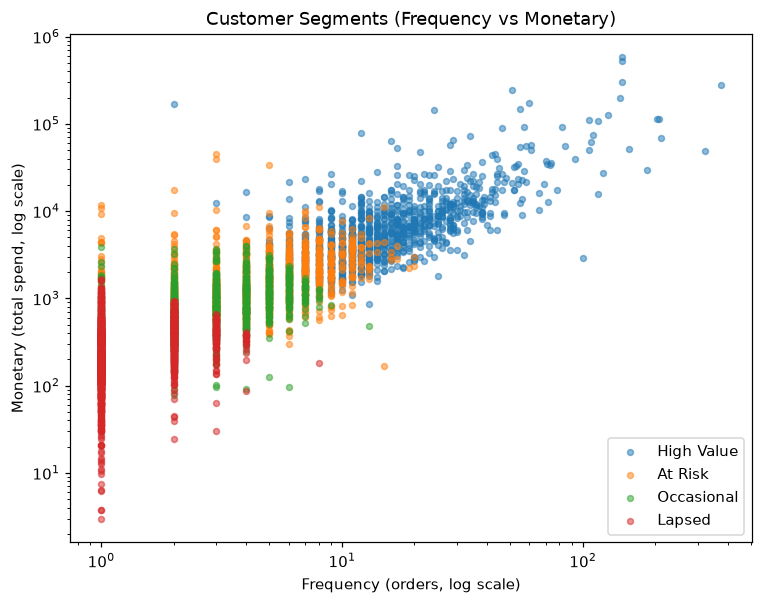

In [15]:
display(Image("../outputs/figures/15_customer_segments_scatter.png"))

Four segments came out of this: **High Value** customers who buy often and recently, **At Risk** customers who used to spend a reasonable amount but have gone quiet, **Occasional** customers who buy a little but recently, and **Lapsed** customers who made one or two small purchases a long time ago and never came back.

## 8. Churn prediction

The dataset has no real churn label, so `scripts/churn_prediction.py`
builds a proxy: a customer counts as churned if they bought something
before a cutoff date but nothing in the 90 days after. All features are
built only from data before the cutoff to avoid leaking the future into
the model.

In [16]:
metrics[metrics["model"].str.contains("churn")]

,model,metric,value
6,churn_logistic_regression,precision,0.750
7,churn_logistic_regression,recall,0.810
8,churn_logistic_regression,F1,0.779
9,churn_logistic_regression,ROC_AUC,0.812
10,churn_random_forest,precision,0.737
11,churn_random_forest,recall,0.787
12,churn_random_forest,F1,0.761
13,churn_random_forest,ROC_AUC,0.793


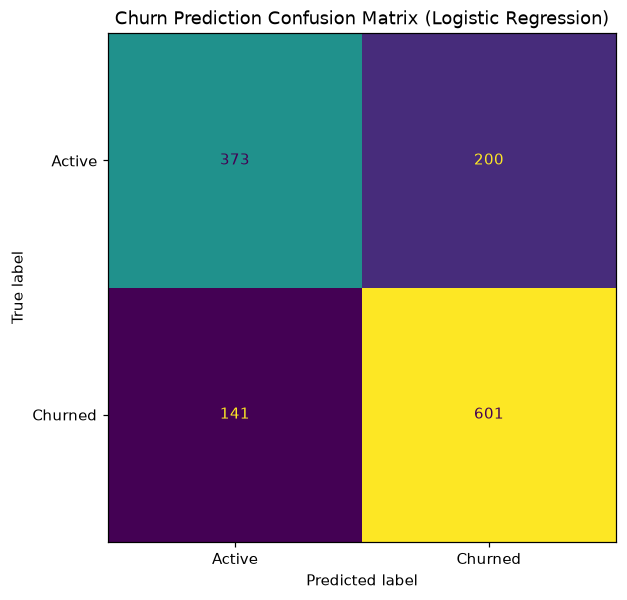

In [17]:
display(Image("../outputs/figures/17_churn_confusion_matrix.png"))

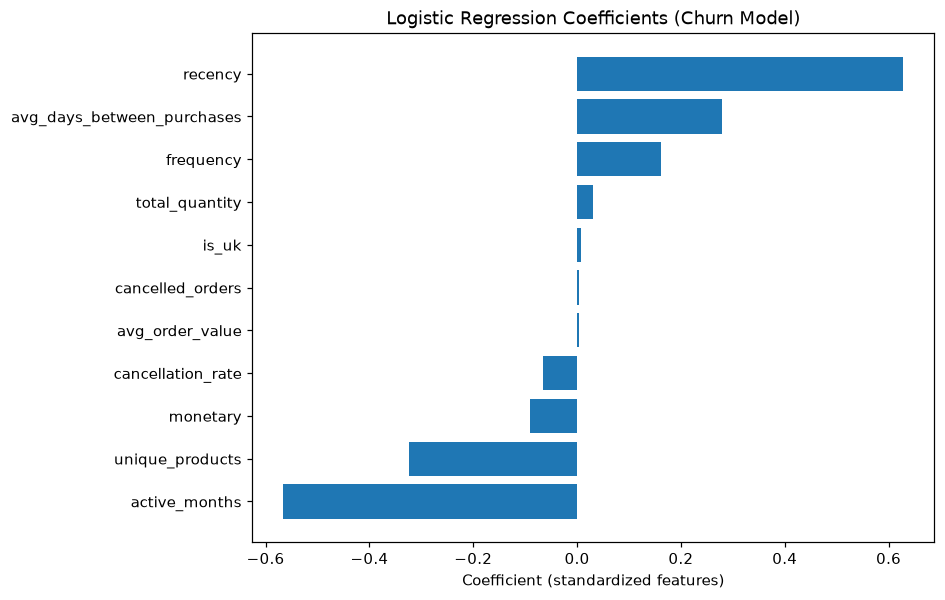

In [18]:
display(Image("../outputs/figures/18_churn_feature_importance.png"))

Recency is by far the strongest signal, which makes sense: the longer it has been since a customer's last order, the more likely they are to stay quiet. Customers who have been active across more months and bought a wider range of products are less likely to churn.

## 9. Price estimation

`scripts/price_prediction.py` estimates a product's unit price from its
description (as TF-IDF text features), quantity, country, and time of
purchase. This is price estimation, not dynamic pricing or elasticity
modeling. To keep training fast, it uses a reproducible sample of 60,000
rows out of the ~777k purchase rows.

In [19]:
metrics[metrics["model"].str.contains("price")]

,model,metric,value
14,price_baseline,MAE,1.822
15,price_baseline,RMSE,4.475
16,price_prediction,MAE,1.311
17,price_prediction,RMSE,3.692
18,price_prediction,R2,0.287


In [20]:
price_examples = pd.read_csv("../outputs/tables/price_prediction_examples.csv")
price_examples[["description", "quantity", "country_group", "actual_price", "predicted_price"]].head(10)

,description,quantity,country_group,actual_price,predicted_price
0,"GARLAND , WOODEN "" HAPPY EASTER""",1,United Kingdom,1.25,2.668643
1,LARGE CIRCULAR MIRROR MOBILE,6,United Kingdom,1.25,5.298559
2,ASSORTED ICE CREAM FRIDGE MAGNETS,24,Switzerland,0.65,2.849180
3,TV DINNER TRAY VINTAGE PAISLEY,6,Portugal,4.95,4.244113
4,TEA COSY VINTAGE UNION JACK,1,United Kingdom,3.75,4.432449
5,PAPER BUNTING RETRO SPOTS,2,United Kingdom,2.95,4.032937
6,CHARLOTTE BAG SUKI DESIGN,100,United Kingdom,0.72,0.218595
7,HANGING HEART JAR T-LIGHT HOLDER,12,United Kingdom,1.25,1.300247
8,LADIES & GENTLEMEN METAL SIGN,2,United Kingdom,2.55,2.088762
9,POTTERING MUG,1,United Kingdom,1.25,0.593384


The Ridge model clearly beats the median price baseline, since product descriptions are strongly tied to price, but it is far from perfect: quantity discounts and price changes over time add noise that a simple linear model cannot fully capture.

## 10. Recommendations

`scripts/recommendation_system.py` builds an item-item collaborative
filtering recommender: products that tend to be bought by the same
customers are considered similar, and a customer gets recommended
products similar to what they have already bought.

In [21]:
metrics[metrics["model"] == "recommendation"]

,model,metric,value
19,recommendation,HitRate@5,0.21


In [22]:
similar = pd.read_csv("../outputs/tables/recommendation_similar_products_examples.csv")
similar[similar["source_stock_code"] == similar["source_stock_code"].iloc[0]][["source_description", "description", "similarity"]]

,source_description,description,similarity
0,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.600922
1,WHITE HANGING HEART T-LIGHT HOLDER,HEART OF WICKER LARGE,0.463039
2,WHITE HANGING HEART T-LIGHT HOLDER,CANDLEHOLDER PINK HANGING HEART,0.450008
3,WHITE HANGING HEART T-LIGHT HOLDER,HEART OF WICKER SMALL,0.444471
4,WHITE HANGING HEART T-LIGHT HOLDER,CREAM HEART CARD HOLDER,0.415702


In [23]:
customer_recs = pd.read_csv("../outputs/tables/recommendation_customer_examples.csv")
customer_recs.head(10)

,customer_id,stock_code,description,score
0,16945,22662,LUNCH BAG DOLLY GIRL DESIGN,46.399491
1,16945,21212,PACK OF 72 RETROSPOT CAKE CASES,46.092166
2,16945,84991,60 TEATIME FAIRY CAKE CASES,42.615638
3,16945,85123A,WHITE HANGING HEART T-LIGHT HOLDER,41.681558
4,16945,22551,PLASTERS IN TIN SPACEBOY,41.580318
5,13678,22608,PENS ASSORTED FUNKY JEWELED,2.183666
6,13678,22093,MOTORING TISSUE BOX,2.148634
7,13678,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,2.101956
8,13678,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,2.065068
9,13678,20996,JAZZ HEARTS ADDRESS BOOK,2.054001


A Hit Rate@5 of about 0.21 means that for roughly 1 in 5 customers, at least one of their top 5 recommended products actually shows up in their purchases during the following two months. Given how many products this catalog has, that is a solid signal, not a lucky guess.

## 11. Conclusion

Putting it together: revenue is strongly seasonal and concentrated in the
UK, a small share of customers accounts for a large share of spend, and
simple models built from lag features and RFM statistics can meaningfully
beat naive baselines for forecasting, demand, churn, price, and
recommendations, even without anything more complex than linear models,
tree ensembles, KMeans, and cosine similarity.

The main limitations are worth repeating: churn here is an inactivity
proxy and not a confirmed cancellation, price estimation is not the same
as pricing strategy, and everything is shaped by this being a single
UK-based retailer, so the exact numbers will not generalize to a
different business.